# Why cross-model agreement flags logic errors: consensus audit demo

This notebook is a runnable demo of **`eval.py`** from the evaluation artifact *"Why cross-model agreement flags logic errors"*. The artifact is a consensus-mechanism audit (T4) on dataset **E**: CPU only, **$0**, no LLM calls.

**Setting.** Every English sentence in dataset E was translated to first-order logic (NL→FOL) by LLMs from 7 vendor families. We don't use a gold formula. Instead, each candidate formula is compared with the other families' outputs using a z3 check for **equivalence modulo vocabulary (eqmv)**.
- **`c_score_align`** (graded) is the share of *other-family* peers whose output is **not** eqmv-equivalent to the candidate. High means disputed, so the candidate is likely wrong.
- **`END_MAJ`** (binary) says the candidate is *endorsed* when a majority of peers agree with it.

**What `eval.py` does:**
1. Copies the inputs and computes the label-free pairwise eqmv matrix over all parseable outputs of the 700 E sentences (`src/run_matrix.py`, z3). This step is heavy.
2. Part A (`src/part_a.py`): gates G0/G1/G2, the exact **e/d decomposition** of binary consensus (e = P(endorsed | ERROR), d = P(not endorsed | CORRECT), and AUROC_b = 1 − (e+d)/2), and the mechanism tests M1, M2, NET, SCATTER, M3-local and M4.
3. Part B (`src/record.py`): a file-sourced verified record of iteration 2. Then audits, **`figures(A)`** and **`build_eval_out(A, B)`**.

**What this demo runs.** Steps 1–3 read the original dependency workspaces and a z3 matrix that takes hours, so the notebook **loads their precomputed outputs** (`part_a.json`, record summary, tables, audits) from `mini_demo_data.json`. It then runs `eval.py`'s own `figures()` and `build_eval_out()` code, almost unchanged, on a curated set of **100 R_AB rows**: 12 ERROR + 12 CORRECT per stratum, plus 4 rows that are not consensus-scorable.

Headline results (full run, 2,672 scorable R_AB rows): graded `c_score_align` AUROC **0.784** vs binary `END_MAJ` **0.669**. Binary consensus gets worse on long sentences, and the driver is correct outputs losing endorsement (d). Wrong translations *scatter*: SI_err 0.159 vs SI_cor 0.760.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, matplotlib, scikit-learn — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0', 'scikit-learn==1.6.1')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports

This is the original import block from `eval.py`. Three pieces are left out because they only make sense when the file runs as a script:
- The `PYTHONHASHSEED=0` re-exec. It only matters for the z3 eqmv matrix (`align()`/`fp()` hash strings), and that matrix is precomputed here.
- `sys.path.insert(..., "src")`. The `src/` modules are not used in the demo.
- `resource.setrlimit(RLIMIT_AS, 20 GB)`. A hard address-space cap can break a live Jupyter kernel.

`ROOT` is the current directory instead of `Path(__file__).parent`.

In [2]:
from __future__ import annotations

import argparse
import json
import os
import subprocess
import sys
import time
from pathlib import Path

# if os.environ.get("PYTHONHASHSEED") != "0":  # eqmv's align()/fp() hash strings: fix the seed for reproducibility
#     os.environ["PYTHONHASHSEED"] = "0"
#     os.execv(sys.executable, [sys.executable] + sys.argv)   # (script only; the eqmv matrix is precomputed in this demo)

import numpy as np
import pandas as pd
from loguru import logger

ROOT = Path.cwd()  # was: Path(__file__).resolve().parent
# sys.path.insert(0, str(ROOT / "src"))  # src/ modules are not needed: their outputs are loaded from mini_demo_data.json
(ROOT / "logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "eval.log", rotation="30 MB", level="DEBUG")

# import resource  # noqa: E402
# resource.setrlimit(resource.RLIMIT_AS, (20 * 1024 ** 3, 20 * 1024 ** 3))  # 29 GB container; fail fast instead of OOM

# notebook-only extras (display + summary)
import matplotlib.pyplot as plt
from IPython.display import Image, display
from sklearn.metrics import roc_auc_score

## Load the demo data

The notebook fetches `mini_demo_data.json` from GitHub and falls back to a local copy when the URL isn't reachable.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_e4aqYfQhdCkX/round-3/evaluation-2/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("rows:", len(data["rows"]), "| part A keys:", list(data["A"].keys()))

Curated demo subset for the T4 consensus-mechanism audit (dataset E): 100 R_AB rows (12 ERROR + 12 CORRECT per stratum, plus 4 not consensus-scorable), precomputed part A/B results, tables and audits read by eval.py's figures()/build_eval_out().
rows: 100 | part A keys: ['frame_info', 'gates', 'G2', 'nontransitivity', 'matrix_summary', 'population', 'vocab_exact', 'cuts_headline', 'stratified', 'graded_vs_binary', 'system_class_cut', 'M1_M2', 'NET', 'SCATTER', 'M3_local', 'M4']


## Config

The original script takes one CLI parameter, `--stage mini|rab|all`, which picks how many sentences the eqmv matrix covers (12 / 292 R_AB / all 700). The matrix is precomputed here, so the demo has one knob instead: **`N_EXAMPLES`**, the number of R_AB rows turned into per-row examples by `build_eval_out()`. It takes an evenly strided subset of the 100 curated rows.

In [5]:
# Number of R_AB rows (out of the 100 curated in mini_demo_data.json) processed by build_eval_out().
# Original full run: all 2,686 R_AB rows (2,672 consensus-scorable), i.e. `uv run eval.py --stage all`.
N_EXAMPLES = 100

ROWS = data["rows"][:: max(1, len(data["rows"]) // N_EXAMPLES)][:N_EXAMPLES]
print(f"{len(ROWS)} rows selected; labels:", pd.Series([r["final_label"] for r in ROWS]).value_counts().to_dict())

100 rows selected; labels: {'ERROR': 52, 'CORRECT': 48}


## Helper: `jdump`

This is `eval.py`'s JSON writer, unchanged. It turns numpy scalars into Python numbers with `.item()`.

In [6]:
def jdump(p: Path, o):
    p.write_text(json.dumps(o, indent=1, default=lambda x: x.item() if hasattr(x, "item") else str(x)))

## What the label-free matrix looks like (context)

`src/run_matrix.py` groups each sentence's parseable outputs into **nodes**, one per canonical formula. It then checks every pair of nodes with z3 eqmv. The results are shipped as `pairwise_classes_E.jsonl`. Below are three sentences from the demo rows (short, medium, long). For each one we print the number of distinct canonical formulas, the vendor families behind each node, and the formulas themselves. Longer sentences split into many small classes: wrong translations rarely match each other.

In [7]:
for s in sorted(data["pairwise_examples"], key=lambda s: s["words"]):
    txt = next((r["text"] for r in data["rows"] if r["sentence_id"] == s["sentence_id"]), "")
    print(f"=== {s['sentence_id']} | {s['source_stratum']} | words={s['words']} | n_conditions={s['n_conditions']} | {len(s['nodes'])} distinct canonical formulas")
    print("TEXT:", txt)
    for nd in sorted(s["nodes"], key=lambda n: -len(n["rows"]))[:4]:
        fams = sorted({r["family"] for r in nd["rows"]})
        print(f"  [{len(nd['rows'])} outputs; {', '.join(fams)}]  {nd['canon_fol'][:160]}")
    print()

=== 444cf16a5b26 | CTRL | words=4 | n_conditions=0 | 4 distinct canonical formulas
TEXT: Taylor is Emily's friend.
  [7 outputs; deepseek, google, meta, microsoft, mistral, qwen]  Friend(taylor, emily)
  [2 outputs; cohere, qwen]  Friend(Taylor, Emily)
  [2 outputs; google, openai]  FriendOf(taylor, emily)
  [1 outputs; meta]  Friend(emily, taylor)

=== 169971c6fe54 | L20 | words=22 | n_conditions=5 | 11 distinct canonical formulas
TEXT: An animal is a mammal if it has hair or fur, gives birth to live young, and feeds its offspring with milk.
  [2 outputs; google, qwen]  ∀v0 ((Animal(v0) → (Mammal(v0) ↔ (((HasHair(v0) ∨ HasFur(v0)) ∧ GivesBirthToLiveYoung(v0)) ∧ FeedsOffspringWithMilk(v0)))))
  [1 outputs; mistral]  ∀v0 (((((Animal(v0) ∧ (Has(v0, hair) ∨ Has(v0, fur))) ∧ GivesBirthToLiveYoung(v0)) ∧ FeedsOffspringWith(v0, milk)) → Mammal(v0)))
  [1 outputs; openai]  ∀v0 (((((Animal(v0) ∧ (Has(v0, hair) ∨ Has(v0, fur))) ∧ GivesBirthToLiveYoung(v0)) ∧ FeedsOffspringWithMilk(v0)) → Mammal

## Stages 1–3 of `main()`: matrix, part A, part B (loaded, not recomputed)

In `eval.py`, `main()` runs `copy_inputs.py` and `run_matrix.py`, then `part_a.run()`, then the `record.py` functions (`exp6_tables`, `radj_gate`, `pt_vs_s4`, `corrections`, …). All of these read absolute server paths from the iteration-1/2 workspaces, and the matrix needs z3 and hours of CPU. The cell below keeps the original calls as comments and loads their results instead:
- `A` is the full `results/part_a.json`: gates, e/d cuts, M1–M4, NET, SCATTER and cost.
- `B` holds the record summary plus the `pt_vs_s4` re-run rows (from `tables/pt_vs_s4_rerun.csv`), which `build_eval_out` reads.

In [8]:
t0 = time.time()
# subprocess.run([py, str(ROOT / "src" / "copy_inputs.py")], check=True)
# for st in stages: subprocess.run([py, str(ROOT / "src" / "run_matrix.py"), "--stage", st], check=True)
# import part_a
# import record as RC
# A = part_a.run()
A = data["A"]
logger.info(f"PART A done {time.time() - t0:.0f}s")
# B = {"summary": {}}; B["summary"]["exp6"] = RC.exp6_tables(); ... B["pt_vs_s4"] = RC.pt_vs_s4(); ...
B = {"summary": data["B"]["summary"], "pt_vs_s4": data["B"]["pt_vs_s4"]}
logger.info(f"PART B done {time.time() - t0:.0f}s")
# audits (audit/rederive.py, audit/m2_specificity.py) -> their JSON outputs are in data["audit"]

g = A["gates"]
print("G0 pass:", g["G0"]["pass"], "| G1 AUROC R_AB pooled:", round(g["G1"]["auroc_R_AB_pooled"], 4), "| G2 mismatch rate:", round(A["G2"]["mismatch_rate"], 4))

11:42:05|INFO   |PART A done 0s


11:42:05|INFO   |PART B done 0s


G0 pass: True | G1 AUROC R_AB pooled: 0.7824 | G2 mismatch rate: 0.0033


## Figures (`figures(A)`)

This is the original plotting function. The only changes are that the three CSV reads (`ed_decomposition_cuts`, `graded_trace_c_score_*`) now read the same tables from `data["tables"]`, and the `matplotlib.use("Agg")` call is dropped. It draws four figures from the full-run part-A results:
1. **fig1**: e and d of `END_MAJ` by number of conditions and by words tercile, for three label regimes.
2. **fig2**: AUROC(k) as the peer pool grows from k=1 to k=6 other families, the cost per sentence, and the per-tercile curves.
3. **fig3**: the scatter index. SI_err is the chance that two cross-family *wrong* outputs are equivalent; SI_cor is the same for correct outputs.
4. **fig4**: the graded consensus ROC with the named binary operating points.

In [9]:
def figures(A: dict):
    import matplotlib
    # matplotlib.use("Agg")  # notebook: keep the inline backend (figures are saved to files and shown below)
    import matplotlib.pyplot as plt
    plt.rcParams.update({"font.size": 9, "pdf.fonttype": 42, "axes.spines.top": False, "axes.spines.right": False})
    F = ROOT / "figures"
    F.mkdir(exist_ok=True)
    cuts = pd.DataFrame(data["tables"]["ed_decomposition_cuts"])  # was: pd.read_csv(ROOT / "tables" / "ed_decomposition_cuts.csv", comment="#")
    C_E, C_D = "#1b6ca8", "#c8553d"
    # (1) e and d vs n_conditions bin and words tercile, per regime (END_MAJ)
    regs = ["R_AB", "R_A", "VOCAB_EXACT"]
    fig, ax = plt.subplots(2, 3, figsize=(10, 5.6), sharey=True)
    spec1 = {"type": "multi-panel errorbar", "rule": "END_MAJ", "panels": []}
    for j, rg in enumerate(regs):
        for i, (dim, order) in enumerate((("ncond_bin", ["0-1", "2", "3", "4+"]), ("words_tercile", ["T1", "T2", "T3"]))):
            sub = cuts[(cuts.regime == rg) & (cuts.dim == dim) & (cuts.rule == "MAJ")].set_index("cell").reindex(order)
            x = np.arange(len(order))
            for q, col, off in (("e", C_E, -0.08), ("d", C_D, 0.08)):
                y = sub[q].values
                lo = sub[f"{q}_ci_lo"].values
                hi = sub[f"{q}_ci_hi"].values
                err = np.array([np.where(np.isnan(lo), 0, y - lo), np.where(np.isnan(hi), 0, hi - y)])
                ax[i, j].errorbar(x + off, y, yerr=err, fmt="o-", color=col, capsize=3, lw=1.4, ms=4,
                                  label=f"{q} = {'P(endorsed | ERROR)' if q == 'e' else 'P(not endorsed | CORRECT)'}")
            ax[i, j].set_xticks(x, order)
            ax[i, j].set_title(f"{rg} — by {dim.replace('_', ' ')}", fontsize=9)
            ax[i, j].set_ylim(-0.02, 1.02)
            ax[i, j].grid(axis="y", alpha=0.3)
            spec1["panels"].append({"regime": rg, "dim": dim, "cells": order, "e": sub.e.tolist(), "d": sub.d.tolist(),
                                    "n_err": sub.n_err.tolist(), "n_cor": sub.n_cor.tolist()})
    ax[0, 0].set_ylabel("rate")
    ax[1, 0].set_ylabel("rate")
    ax[0, 0].legend(fontsize=7, frameon=False, loc="upper left")
    fig.suptitle("Binary majority consensus: AUROC_b = 1 − (e + d)/2. Error endorsement e falls with length; correct divergence d rises faster",
                 fontsize=9)
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(F / f"fig1_e_d_by_complexity.{ext}", dpi=200)
    plt.close(fig)
    jdump(F / "fig1_e_d_by_complexity.json", spec1)
    # (2) AUROC(k) with draw band, per tercile, $/sentence secondary axis
    r = A["M4"]["random_k_primary"]
    ks = sorted(int(k) for k in r["k"])
    m = [r["k"][str(k)]["auroc_mean"] if str(k) in r["k"] else r["k"][k]["auroc_mean"] for k in ks]
    kk = {int(k): v for k, v in r["k"].items()}
    lo = [kk[k]["auroc_ci_of_draw_mean"][0] for k in ks]
    hi = [kk[k]["auroc_ci_of_draw_mean"][1] for k in ks]
    bl = [kk[k]["draw_band"][0] for k in ks]
    bh = [kk[k]["draw_band"][1] for k in ks]
    fig, ax = plt.subplots(1, 2, figsize=(10, 4.6))
    ax[0].fill_between(ks, lo, hi, color="#1b6ca8", alpha=0.15, label="cluster-bootstrap 95% CI of draw mean")
    ax[0].fill_between(ks, bl, bh, color="#1b6ca8", alpha=0.35, label="2.5–97.5% band across 50 draws")
    ax[0].plot(ks, m, "o-", color="#1b6ca8", label="AUROC(k), graded consensus")
    ax[0].plot(ks, [kk[k]["endmaj_auroc_mean"] for k in ks], "s--", color="#777777", label="END_MAJ at k (binary)")
    ax[0].axhline(0.95 * kk[max(ks)]["auroc_mean"], color="k", lw=0.8, ls=":", label=f"95% of k={max(ks)}; k95={r['k95']}")
    ax[0].axhline(0.712, color="#c8553d", lw=0.8, ls="--", label="local judge 0.712 (R_AB)")
    ax[0].set_xlabel("k = number of other vendor families in the peer pool")
    ax[0].set_ylabel("AUROC (R_AB, rows with all 7 families)")
    ax2 = ax[0].twinx()
    cost = [c["usd_per_sentence_expected"] * 1000 for c in A["M4"]["cost"]["by_k"]]
    ax2.plot(ks, cost, "d-", color="#8a6d3b", alpha=0.7, lw=1)
    ax2.set_ylabel("generation $ per sentence ×1000 (expected)", color="#8a6d3b")
    ax[0].legend(fontsize=6.5, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=2)
    for t, col in (("T1", "#4c9f70"), ("T2", "#1b6ca8"), ("T3", "#c8553d")):
        ax[1].plot(ks, [kk[k]["tercile_auroc_mean"][t] for k in ks], "o-", color=col, label=f"words {t} (k95={r['k95_tercile'][t]})")
    ax[1].set_xlabel("k")
    ax[1].set_ylabel("AUROC within words tercile")
    ax[1].legend(fontsize=7, frameon=False)
    ax[1].set_title("Long sentences need more peers", fontsize=9)
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(F / f"fig2_auroc_k.{ext}", dpi=200)
    plt.close(fig)
    jdump(F / "fig2_auroc_k.json", {"type": "line+band, twin axis", "k": ks, "auroc_mean": m, "ci": [lo, hi], "band": [bl, bh],
                                     "usd_per_sentence_x1000": cost, "tercile": {t: [kk[k]["tercile_auroc_mean"][t] for k in ks] for t in ("T1", "T2", "T3")},
                                     "k95": r["k95"], "k95_tercile": r["k95_tercile"]})
    # (3) SI_err vs SI_cor by n_conditions
    S = A["SCATTER"]["by_ncond_bin"]
    order = ["0-1", "2", "3", "4+"]
    fig, ax = plt.subplots(figsize=(5.2, 4.4))
    x = np.arange(len(order))
    for q, col, lab, off in (("SI_cor", "#4c9f70", "SI_cor: P(two cross-family CORRECT outputs equivalent)", -0.08),
                             ("SI_err", "#c8553d", "SI_err: P(two cross-family ERROR outputs equivalent)", 0.08),
                             ("joint_fail", "#777777", "joint failure: P(both ERROR)", 0.0)):
        y = [S[b][q]["mean"] for b in order]
        l = [S[b][q]["ci"][0] for b in order]
        h = [S[b][q]["ci"][1] for b in order]
        err = np.array([[yy - ll if ll is not None else 0 for yy, ll in zip(y, l)], [hh - yy if hh is not None else 0 for yy, hh in zip(y, h)]])
        ax.errorbar(x + off, y, yerr=err, fmt="o-" if q != "joint_fail" else "s:", color=col, capsize=3, label=lab, lw=1.3, ms=4)
    ax.set_xticks(x, [f"{b}\n(n={S[b]['SI_err']['n_sent']}/{S[b]['SI_cor']['n_sent']})" for b in order])
    ax.set_xlabel("n_conditions bin (sentences with SI_err / SI_cor)")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=6.5, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=1)
    ax.set_title("Wrong translations scatter: errors are rarely identical", fontsize=9)
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(F / f"fig3_scatter_index.{ext}", dpi=200)
    plt.close(fig)
    jdump(F / "fig3_scatter_index.json", {"type": "errorbar", "bins": order, **{q: [S[b][q] for b in order] for q in ("SI_err", "SI_cor", "joint_fail")}})
    # (4) graded ROC with named operating points
    fig, ax = plt.subplots(figsize=(4.4, 4.2))
    for nm, fn, col, key in (("c_score_align (frozen)", "graded_trace_c_score_align.csv", "#1b6ca8", "auroc_c_score_align"),
                             ("c_score_exact (aligner-free)", "graded_trace_c_score_exact.csv", "#c8553d", "auroc_c_score_exact")):
        tr = pd.DataFrame(data["tables"][fn[:-4]])  # was: pd.read_csv(ROOT / "tables" / fn)
        xs = [0] + tr.d_t.tolist() + [1]
        ys = [0] + (1 - tr.e_t).tolist() + [1]
        au = A["graded_vs_binary"][key]
        ax.plot(xs, ys, "-", color=col, label=f"{nm} AUROC {au:.3f}")
    for (k, v), mk in zip(A["graded_vs_binary"]["named_points"].items(), ("o", "s", "^")):
        ax.plot(v["d"], 1 - v["e"], mk, color="k", ms=6)
        ax.annotate(f"{k.split(' (')[0]}\n(e={v['e']:.2f}, d={v['d']:.2f})", (v["d"], 1 - v["e"]), fontsize=6.5, xytext=(6, -14), textcoords="offset points")
    ax.plot([0, 1], [0, 1], ":", color="#999999")
    ax.set_xlabel("d = FPR (CORRECT rows flagged)")
    ax.set_ylabel("1 − e = TPR (ERROR rows flagged)")
    ax.legend(fontsize=7, frameon=False, loc="lower right")
    ax.set_title(f"Graded consensus ROC (R_AB, n={A['population']['consensus_scorable']:,})", fontsize=9)
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(F / f"fig4_graded_roc.{ext}", dpi=200)
    plt.close(fig)
    jdump(F / "fig4_graded_roc.json", {"type": "ROC", "named_points": A["graded_vs_binary"]["named_points"],
                                        "source": ["tables/graded_trace_c_score_align.csv", "tables/graded_trace_c_score_exact.csv"]})

fig1_e_d_by_complexity


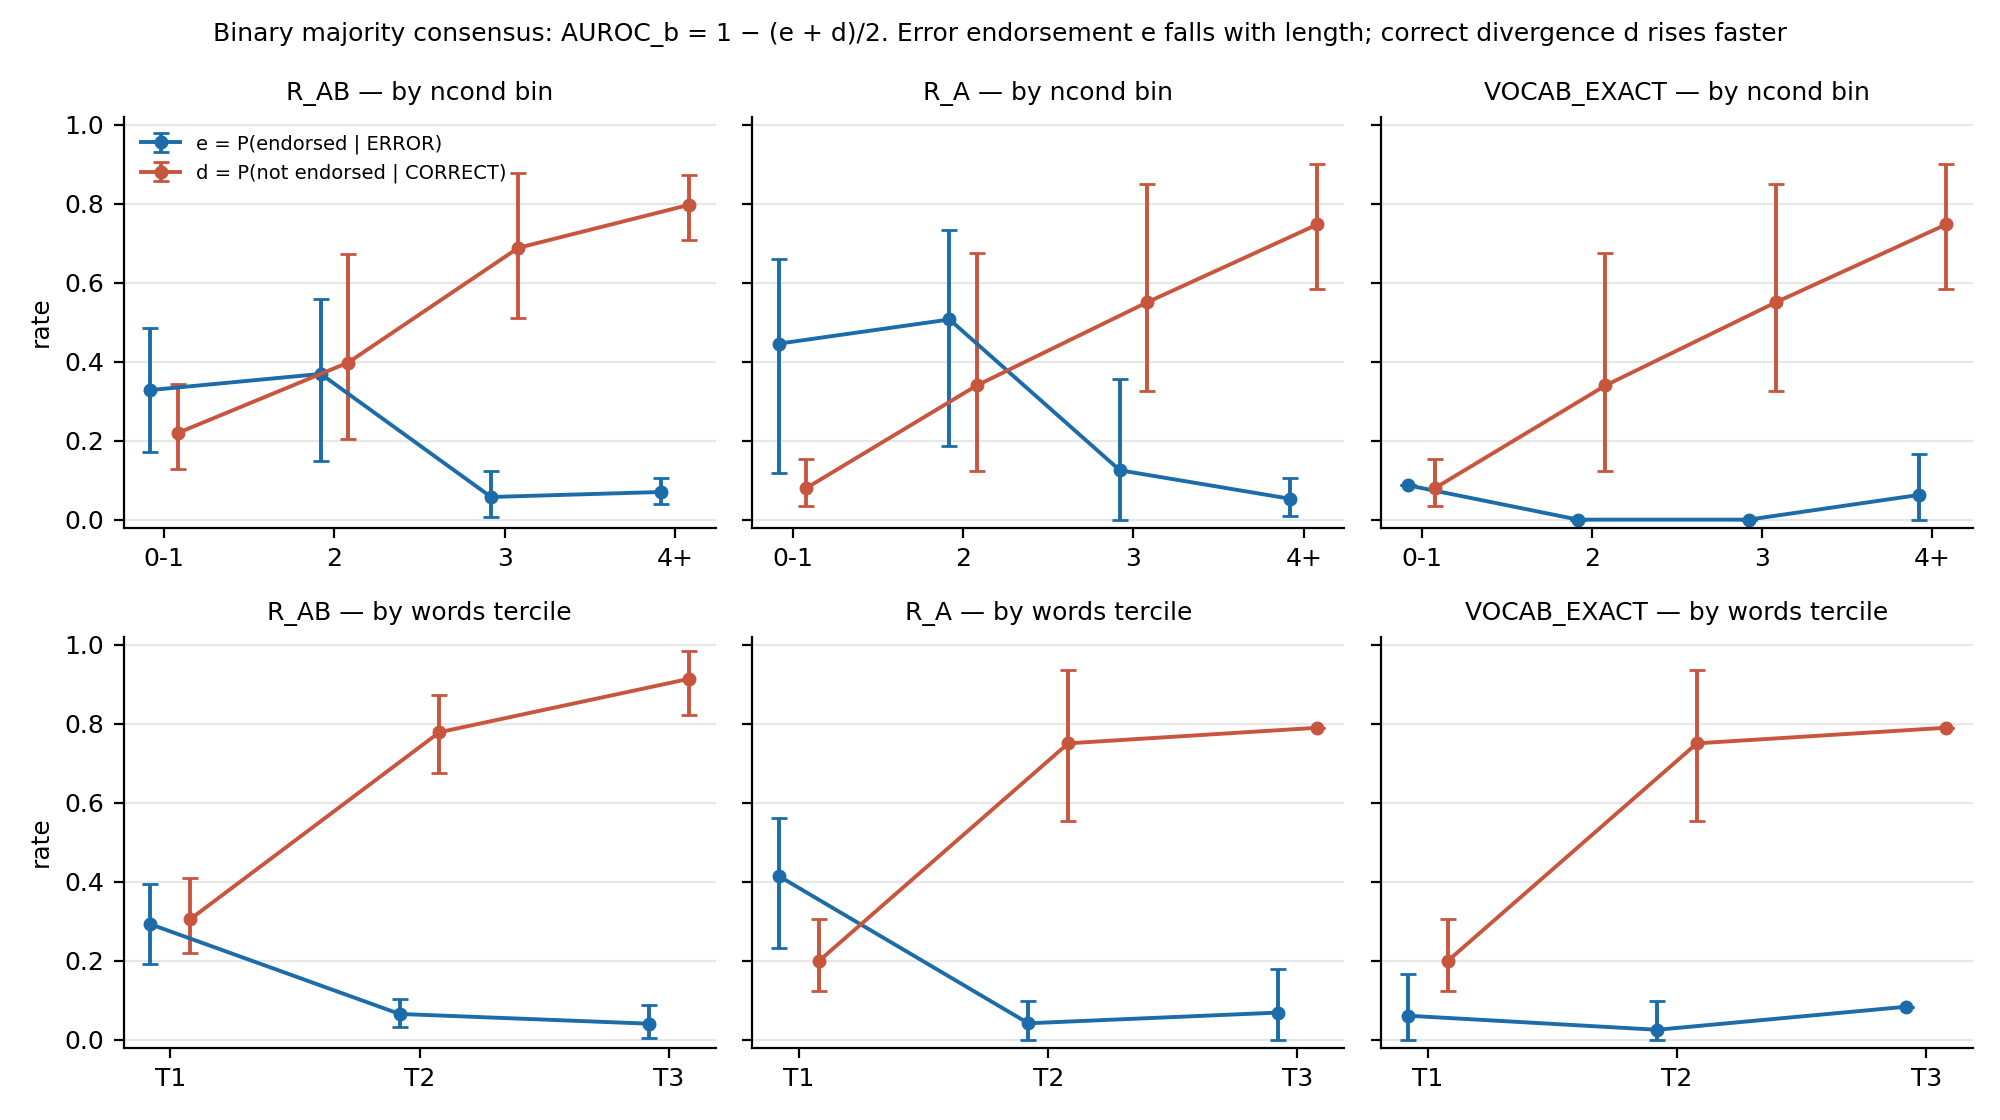

fig2_auroc_k


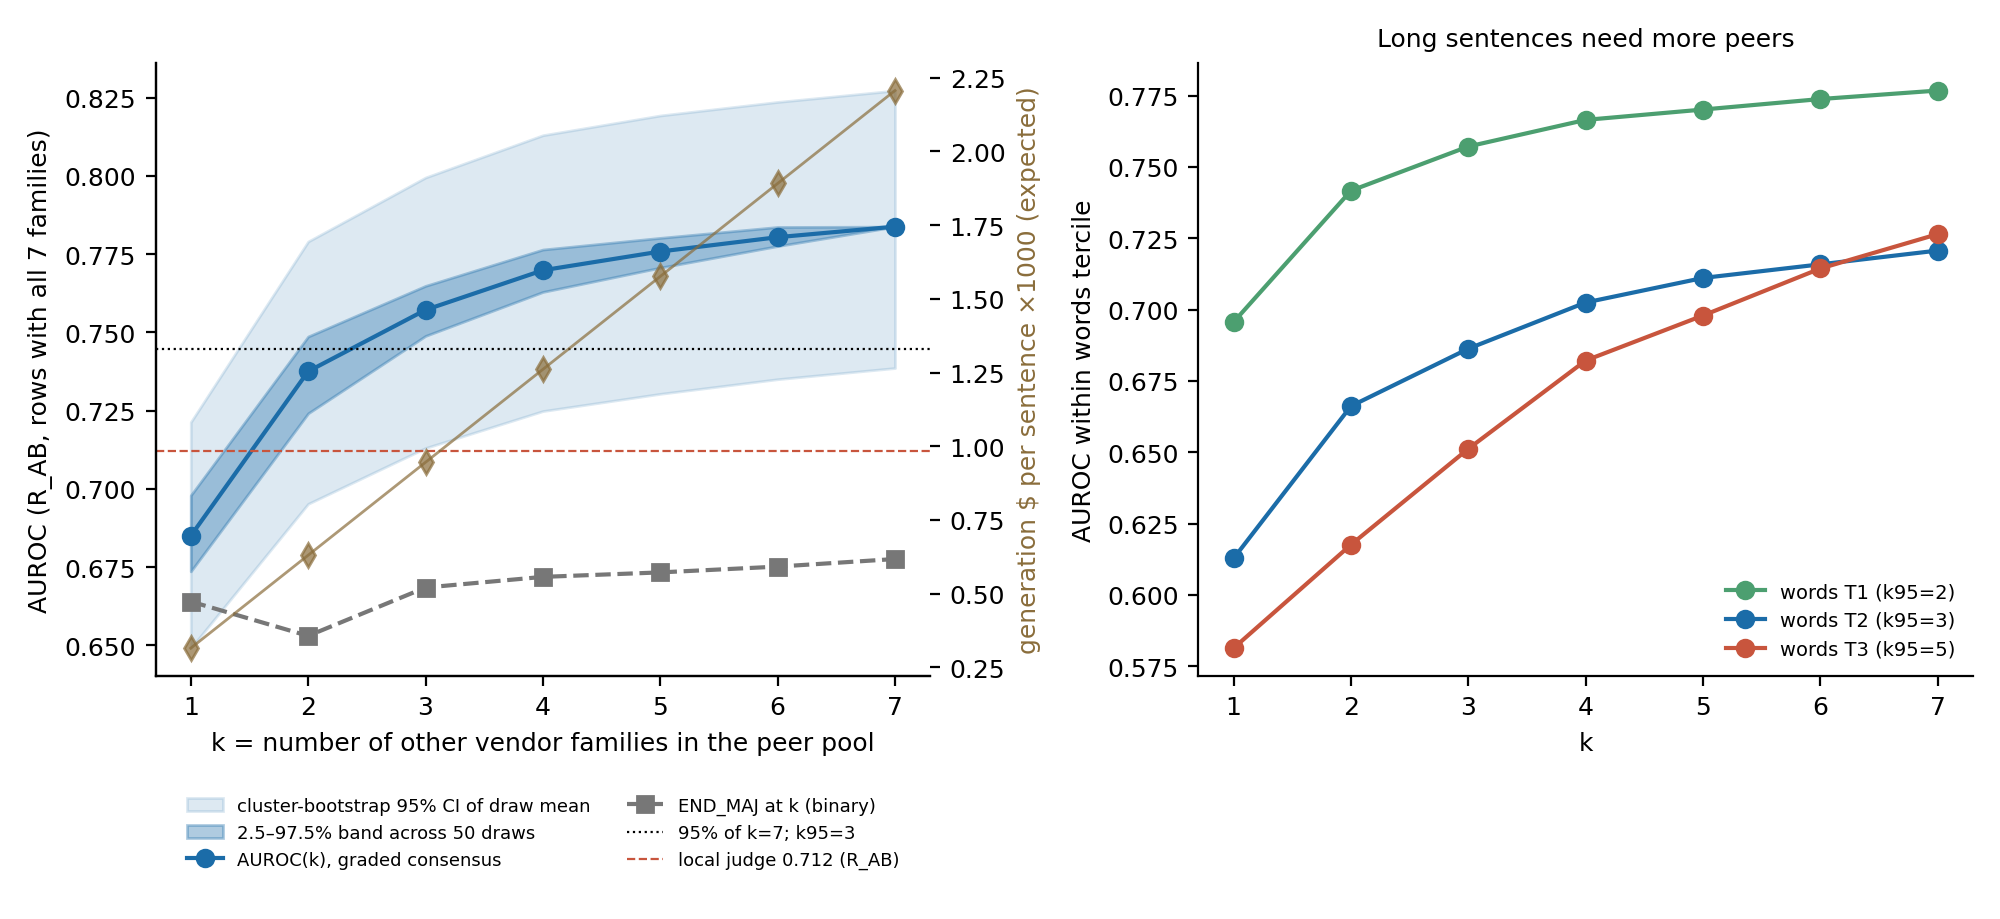

fig3_scatter_index


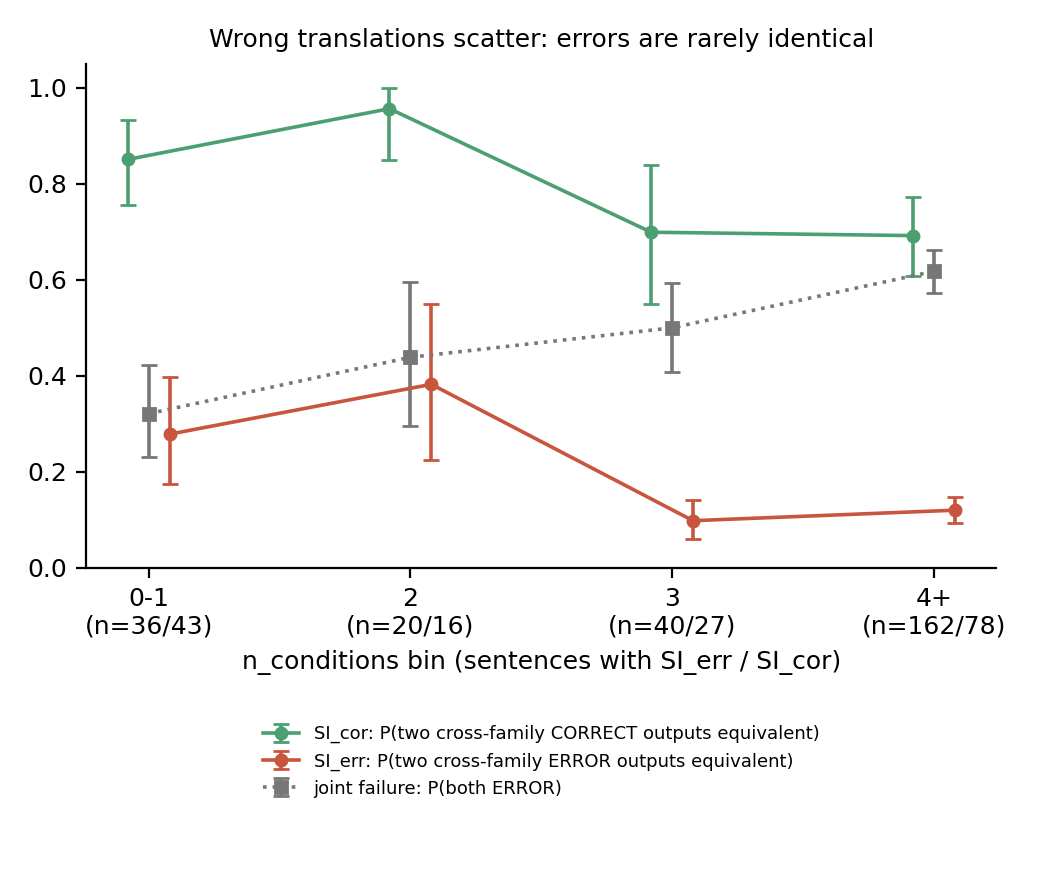

fig4_graded_roc


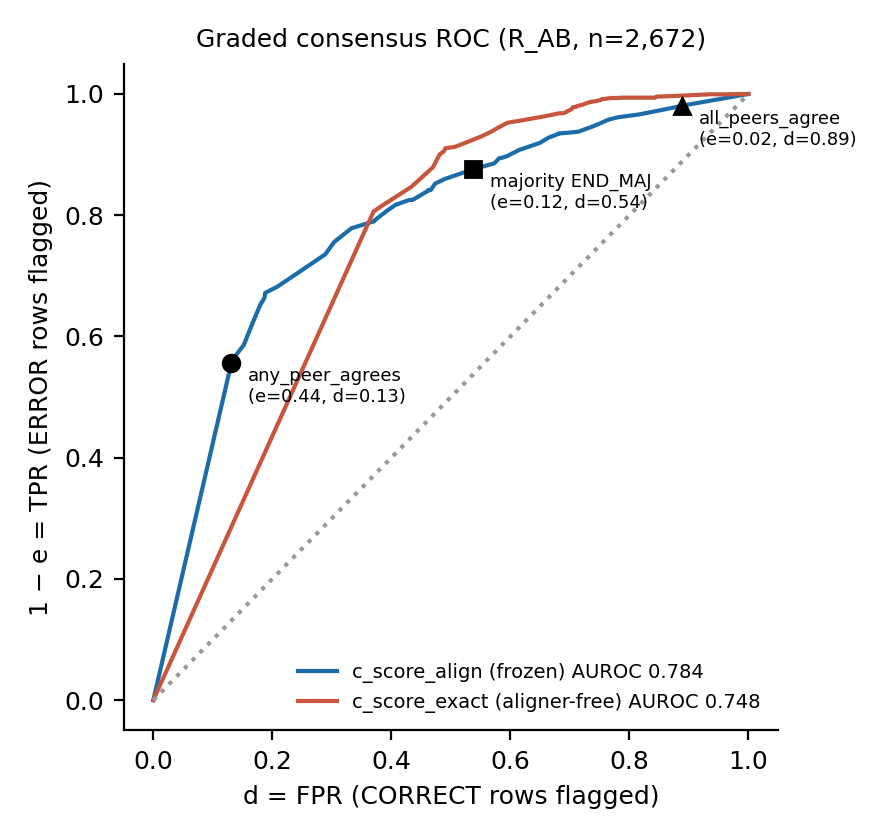

In [10]:
figures(A)
for f in ("fig1_e_d_by_complexity", "fig2_auroc_k", "fig3_scatter_index", "fig4_graded_roc"):
    print(f)
    display(Image(filename=str(ROOT / "figures" / f"{f}.png"), width=760))

## Build the evaluation output (`build_eval_out(A, B)`)

This is the original function. It collects about 335 aggregate metrics (`metrics_agg`) from `A`, `B` and the audits, one example per R_AB row, the pre-registered verdicts (M1, M2, NET, SCATTER, M3-local, M4, LOFO) and the metadata. The only change is that `P` (the consensus-scorable population) and `R` (all R_AB rows) are built from the demo `ROWS` instead of the full pickles. Each example stores its predictions as strings:
- `predict_c_score_align` and `predict_c_score_exact`: graded consensus scores.
- `predict_b_endmaj`, `predict_b_endfam2`, …: binary rules, where 1 means *not endorsed*, i.e. flagged.
- `predict_c_k3_best_oof`: the best cross-fitted 3-family pool.

In [11]:
def build_eval_out(A: dict, B: dict) -> dict:
    P = pd.DataFrame([r for r in ROWS if r["consensus_scorable"]]).set_index("row_key")  # was: pd.read_pickle(ROOT / "results" / "population_RAB.pkl")
    R = pd.DataFrame(ROWS)  # was: pd.read_pickle(ROOT / "results" / "rab_all.pkl")
    head = {(r["regime"], r["rule"]): r for r in A["cuts_headline"]}
    M = A["M1_M2"]
    ma = {}

    def put(k, v):
        if v is not None and not (isinstance(v, float) and np.isnan(v)):
            ma[k] = float(v)
    for (rg, rule), r in head.items():
        s = f"{rule.lower()}_{rg}"
        put(f"auroc_b_{s}", r["auroc_b"])
        put(f"e_{s}", r["e"])
        put(f"d_{s}", r["d"])
        for q in ("e", "d", "auroc_b"):
            if r[f"{q}_ci"][0] is not None:
                put(f"{q}_{s}_ci_lo", r[f"{q}_ci"][0])
                put(f"{q}_{s}_ci_hi", r[f"{q}_ci"][1])
        put(f"auroc_c_score_align_{rg}", r["auroc_c"])
    for rule, v in A["stratified"].items():
        if isinstance(v, dict):
            put(f"strat_auroc_b_{rule.lower()}_R_AB", v["strat_auroc_b"])
    put("strat_auroc_c_score_align_R_AB", A["stratified"]["c_score_align_strat_auroc"])
    g = A["graded_vs_binary"]
    for k in ("auroc_c_score_align", "auroc_b_END_MAJ", "delta_graded_minus_binary", "auroc_c_score_exact", "delta_align_minus_exact",
              "share_endorsements_needing_align_or_gran", "share_endorsements_needing_align_or_gran_ERROR", "share_endorsements_needing_align_or_gran_CORRECT"):
        put(k, g[k])
    put("delta_graded_minus_binary_ci_lo", g["delta_ci"][0])
    put("delta_graded_minus_binary_ci_hi", g["delta_ci"][1])
    put("delta_align_minus_exact_ci_lo", g["delta_align_minus_exact_ci"][0])
    put("delta_align_minus_exact_ci_hi", g["delta_align_minus_exact_ci"][1])
    for side, key in (("M1", "zn"), ("M2", "zw")):
        c = M[side]["MAJ|primary"]["coef"]
        other = "zw" if key == "zn" else "zn"
        nm = {"zn": "ncond", "zw": "words"}
        put(f"{side.lower()}_slope_{nm[key]}", c[key]["b"])
        put(f"{side.lower()}_ci_lo", c[key]["ci"][0])
        put(f"{side.lower()}_ci_hi", c[key]["ci"][1])
        put(f"{side.lower()}_slope_{nm[other]}", c[other]["b"])
        put(f"{side.lower()}_slope_{nm[other]}_ci_lo", c[other]["ci"][0])
        put(f"{side.lower()}_slope_{nm[other]}_ci_hi", c[other]["ci"][1])
    for nm, v in A["NET"]["R_AB"].items():
        if "delta_e_plus_d" in v:
            put(f"net_{nm}", v["delta_e_plus_d"])
            put(f"net_{nm}_ci_lo", v["ci"][0])
            put(f"net_{nm}_ci_hi", v["ci"][1])
            put(f"net_{nm}_delta_e", v["delta_e"])
            put(f"net_{nm}_delta_d", v["delta_d"])
        else:
            put(f"net_{nm}", v["sum"])
            put(f"net_{nm}_ci_lo", v["ci"][0])
            put(f"net_{nm}_ci_hi", v["ci"][1])
    put("net_delta_words", A["NET"]["R_AB"]["words_T3_minus_T1"]["delta_e_plus_d"])
    so = A["SCATTER"]["overall"]
    for q in ("SI_err", "SI_cor", "SI_mix", "joint_fail", "same_wrong_any_pair", "cpo_err", "cpo_cor"):
        put(f"{q.lower()}_mean", so[q]["mean"])
        put(f"{q.lower()}_ci_lo", so[q]["ci"][0])
        put(f"{q.lower()}_ci_hi", so[q]["ci"][1])
    put("si_ratio_cor_over_err", so["ratio_SI_cor_over_SI_err_same_sentences"]["ratio"])
    m3 = A["M3_local"]
    put("m3_local_slope_consensus_minus_judge", m3["slope_consensus_minus_judge"])
    put("m3_local_slope_diff_ci_lo", m3["slope_diff_ci"][0])
    put("m3_local_slope_diff_ci_hi", m3["slope_diff_ci"][1])
    r4 = A["M4"]["random_k_primary"]
    put("k95", r4["k95"])
    for k, v in r4["k"].items():
        put(f"m4_auroc_k{k}", v["auroc_mean"])
    put("m4_k3_crossfit_oof_auroc", A["M4"]["fixed_pools"]["3"]["crossfit"]["oof_auroc"] if "3" in A["M4"]["fixed_pools"] else A["M4"]["fixed_pools"][3]["crossfit"]["oof_auroc"])
    put("lofo_min_delta", A["M4"]["LOFO"]["min_delta"])
    put("lofo_full_auroc", A["M4"]["LOFO"]["full_auroc"])
    put("g2_mismatch_rate", A["G2"]["mismatch_rate"])
    put("g1_auroc_R_AB", A["gates"]["G1"]["auroc_R_AB_pooled"])
    put("nontransitivity_rate", A["nontransitivity"]["overall"]["rate"])
    put("vocab_exact_n_err", A["vocab_exact"]["n_err_exact"])
    put("vocab_exact_n_cor", A["vocab_exact"]["n_cor_exact"])
    put("vocab_exact_kappa", A["vocab_exact"].get("kappa_vs_dataset_label"))
    for k, v in A["vocab_exact"].get("auroc", {}).items():
        put(f"vocab_exact_auroc_{k}", v)
    for r in B["pt_vs_s4"]["rows"]:
        if r["quantity"].startswith("AUROC"):
            continue
        tag = f"ptS4_{r['quantity'].replace(' - ', '_minus_')}_{r['subset'].split(' (')[0].replace(' ', '_').replace('+', '')}_{r['statistic']}"
        put(tag, r["delta"])
        put(tag + "_ci_lo", r["ci_lo"])
        put(tag + "_ci_hi", r["ci_hi"])
    put("usd_per_sentence_k7_expected", A["M4"]["cost"]["by_k"][-1]["usd_per_sentence_expected"])
    put("usd_frontier_judge_per_call", A["M4"]["cost"]["frontier_judge_reference"]["usd_per_call"])
    put("openrouter_spend_usd_this_artifact", 0.0)
    au = data["audit"]["rederive"]  # was: json.loads((ROOT / "audit" / "rederive.json").read_text())
    ms = data["audit"]["m2_specificity"]  # was: json.loads((ROOT / "audit" / "m2_specificity.json").read_text())
    put("audit_n_headline_rederived", len(au["comparison"]))
    put("audit_n_headline_match_1e9", sum(v["match_1e-9"] for v in au["comparison"].values()))
    put("audit_perm_p_auroc_c", au["perm_test_auroc_c"]["p"])
    put("audit_placebo_auroc_c_shuffled", au["placebo_auroc_c_shuffled"])
    put("audit_placebo_m2_slope_shuffled", au["placebo_M2_shuffled"]["b"])
    put("audit_placebo_net_shuffled", au["placebo_NET_shuffled"]["delta"])
    put("m2_label_x_words_interaction", ms["interaction_model"]["y:zw"]["b"])
    put("m2_label_x_words_interaction_ci_lo", ms["interaction_model"]["y:zw"]["ci"][0])
    put("m2_label_x_words_interaction_ci_hi", ms["interaction_model"]["y:zw"]["ci"][1])
    put("m2_null_row_shuffle_slope_mean", ms["null_row_shuffle"]["mean"])
    put("m2_null_within_sentence_p", ms["null_within_sentence_shuffle"]["p_obs_ge"])
    # examples: one per R_AB row
    ex = []
    for r in R.itertuples():
        in_p = r.row_key in P.index
        p = P.loc[r.row_key] if in_p else None

        def s(v):
            return "NA" if v is None or (isinstance(v, float) and np.isnan(v)) else (f"{float(v):.6f}" if not isinstance(v, str) else v)
        e = {"input": json.dumps({"text": r.text, "candidate_fol": r.candidate_fol, "family": r.family_vendor, "stratum": r.stratum}, ensure_ascii=False),
             "output": r.final_label,
             "predict_c_score_align": s(r.c_frozen),
             "predict_c_score_exact": s(p.c_score_exact) if in_p else "NA",
             "predict_b_endmaj": s(1 - p.end_MAJ) if in_p else "NA",
             "predict_b_endfam2": s(1 - p.end_FAM2) if in_p else "NA",
             "predict_b_endplur": s(1 - p.end_PLUR) if in_p else "NA",
             "predict_b_endfammaj": s(1 - p.end_FAMMAJ) if in_p else "NA",
             "predict_c_k3_best_oof": s(p.c_k3_best_oof) if in_p else "NA",
             "metadata_sentence_id": r.sentence_id, "metadata_row_key": r.row_key, "metadata_words": int(r.words),
             "metadata_n_conditions": int(r.n_conditions) if r.n_conditions == r.n_conditions else None, "metadata_tier": r.label_tier,
             "metadata_vocab_exact": bool(p.vocab_exact) if in_p else False, "metadata_consensus_scorable": bool(in_p),
             "metadata_fold_E": int(r.fold_E), "metadata_correct_not_equivalent": bool(r.correct_not_equivalent)}
        if in_p:
            e["eval_endmaj_correct"] = float((1 - p.end_MAJ) == p.y_AB)
            e["eval_endorsed_maj"] = float(p.end_MAJ)
        ex.append(e)
    verdicts = {
        "M1": {"verdict": M["M1"]["MAJ|primary"]["verdict"], "rule": "endorsed(END_MAJ) ~ z(ncond)+z(words)+C(stratum) among R_AB ERROR rows; CONFIRMED iff ncond coef < 0 with CI excluding 0; REFUTED iff > 0 with CI excluding 0",
               "rival": "N-version programming (Eckhardt-Lee 1985; Knight-Leveson 1986): coincident failures concentrate on difficult inputs (positive slope)",
               "note": ("EXPLORATORY single-predictor fits are negative, but endorsement of ANY output falls with length (see M2 specificity_caveat), "
                        "so a negative e-slope alone does not show that errors scatter more than correct outputs; SCATTER and NET carry that claim. "
                        f"Placebo on shuffled labels: M1 n_conditions CI covers 0 ({[round(x, 2) for x in au['placebo_M1_shuffled']['ci']]})."),
               "coef_ncond": M["M1"]["MAJ|primary"]["coef"]["zn"], "coef_words": M["M1"]["MAJ|primary"]["coef"]["zw"],
               "sensitivities": {k: v["verdict"] for k, v in M["M1"].items()}},
        "M2": {"verdict": M["M2"]["MAJ|primary"]["verdict"],
               "specificity_caveat": ("PLACEBO FAILS TO FAIL: with row-shuffled labels the same M2 fit still gives a positive words slope "
                                      f"({au['placebo_M2_shuffled']['b']:+.2f} {[round(x, 2) for x in au['placebo_M2_shuffled']['ci']]}); divergence rises with length for "
                                      f"ERROR rows almost as steeply (label x words interaction {ms['interaction_model']['y:zw']['b']:+.2f} "
                                      f"{[round(x, 2) for x in ms['interaction_model']['y:zw']['ci']]}). Only a small label-specific part survives a within-sentence "
                                      f"shuffle (p={ms['null_within_sentence_shuffle']['p_obs_ge']:.3f}). M2 as pre-registered is satisfied but NON-SPECIFIC: long sentences "
                                      "lose endorsement for every output. NET (Delta(e+d)) is the label-specific test and passes its placebo."), "rule": "divergent ~ z(words)+z(ncond)+C(stratum) among R_AB CORRECT rows; CONFIRMED iff words coef > 0 with CI excluding 0",
               "coef_words": M["M2"]["MAJ|primary"]["coef"]["zw"], "sensitivities": {k: v["verdict"] for k, v in M["M2"].items()}},
        "NET": {"verdict": A["NET"]["R_AB"]["words_T3_minus_T1"]["verdict"],
                "placebo": f"shuffled labels: Delta(e+d) {au['placebo_NET_shuffled']['delta']:+.3f} CI {[round(x, 3) for x in au['placebo_NET_shuffled']['ci']]} (covers 0: test is label-specific)", "driver": A["NET"]["R_AB"]["words_T3_minus_T1"]["driver"],
                "rule": "Delta(e+d) top-vs-bottom words tercile: CI upper < 0 -> improves; CI lower > 0 -> degrades; else balanced",
                "ncond_4p_vs_01": A["NET"]["R_AB"]["ncond_4p_minus_01"]["verdict"], "long_pool_words": A["NET"]["long_pool"]["words_T3_minus_T1"]["verdict"],
                "long_pool_ncond": A["NET"]["long_pool"]["ncond_4p_minus_01"]["verdict"]},
        "SCATTER": A["SCATTER"]["prediction"],
        "M3_local": {"slope_consensus_minus_judge": m3["slope_consensus_minus_judge"], "ci": m3["slope_diff_ci"],
                     "verdict": "CONFIRMED" if (m3["slope_diff_ci"][0] or -1) > 0 else ("REFUTED" if (m3["slope_diff_ci"][1] or 1) < 0 else "INCONCLUSIVE"),
                     "rule": "binary-decision correctness ~ z(words): consensus END_MAJ slope minus local judge slope (flag-rate matched), CI > 0 -> CONFIRMED; SECONDARY"},
        "M4": {"verdict": r4["M4_verdict"], "k95": r4["k95"], "k95_tercile": r4["k95_tercile"], "rule": "k95 = smallest k with mean AUROC(k) >= 0.95 AUROC(K_max=7); CONFIRMED iff k95 <= 5"},
        "LOFO": {"verdict": A["M4"]["LOFO"]["verdict"], "rule": A["M4"]["LOFO"]["rule"]}}
    pre = data["prereg_mech"]  # was: json.loads((ROOT / "prereg_mech.json").read_text())
    return {"metadata": {"evaluation_name": "Do wrong translations scatter? Consensus mechanism audit (T4 on dataset E) + verified record",
                         "description": "Label-free pairwise eqmv matrix over every parseable output of the 700 E sentences; exact e/d decomposition of binary cross-family consensus; M1/M2/NET/SCATTER/M3-local/M4; file-sourced verified record of iteration 2. CPU only, $0 OpenRouter.",
                         "gates": {"G0": A["gates"]["G0"], "G1": A["gates"]["G1"], "G2": A["G2"]},
                         "verdicts": verdicts, "deviations": pre["deviations"], "prereg_sha256": data["prereg_sha256"].split()[0],
                         "population": A["population"], "nontransitivity": A["nontransitivity"], "vocab_exact": A["vocab_exact"],
                         "record_summary": B["summary"],
                         "scope_limit": "T4 runs on dataset E only; R_COMP has no candidates yet (the T2 experiment owns them). pairwise_matrix() and ed_decomposition() are shipped for an unchanged iteration-4 rerun on R_COMP."},
            "metrics_agg": ma, "datasets": [{"dataset": "E_R_AB_consensus", "examples": ex}]}

In [12]:
out = build_eval_out(A, B)
jdump(ROOT / "eval_out.json", out)
logger.info(f"eval_out.json written: {len(out['metrics_agg'])} metrics, {len(out['datasets'][0]['examples'])} examples; {time.time() - t0:.0f}s")
print(json.dumps(out["datasets"][0]["examples"][0], indent=1, ensure_ascii=False)[:1500])

11:42:08|INFO   |eval_out.json written: 335 metrics, 100 examples; 4s


{
 "input": "{\"text\": \"When something is depressing, it is sad.\", \"candidate_fol\": \"∀x (Depressing(x) → Sad(x))\", \"family\": \"openai\", \"stratum\": \"CTRL\"}",
 "output": "CORRECT",
 "predict_c_score_align": "0.090909",
 "predict_c_score_exact": "0.090909",
 "predict_b_endmaj": "0.000000",
 "predict_b_endfam2": "0.000000",
 "predict_b_endplur": "0.000000",
 "predict_b_endfammaj": "0.000000",
 "predict_c_k3_best_oof": "0.000000",
 "metadata_sentence_id": "0000c2274e80",
 "metadata_row_key": "b87a8dda4faced11|fewshot_v1",
 "metadata_words": 7,
 "metadata_n_conditions": 1,
 "metadata_tier": "A",
 "metadata_vocab_exact": true,
 "metadata_consensus_scorable": true,
 "metadata_fold_E": 1,
 "metadata_correct_not_equivalent": false,
 "eval_endmaj_correct": 1.0,
 "eval_endorsed_maj": 1.0
}


## Results

**(a) Headline metrics from the full run**, as collected by `build_eval_out` into `metrics_agg`. **(b) The same scores recomputed on the demo rows.** Rows with ERROR count as positives, and a higher score means more likely wrong. The demo subset is small and label-balanced, so its AUROCs are noisy estimates of the full-run values. **(c) Pre-registered verdicts.**

(a) FULL RUN (R_AB, 2,672 scorable rows)
                               metric  value
 AUROC c_score_align (graded, frozen)  0.784
   AUROC c_score_exact (aligner-free)  0.748
      AUROC END_MAJ (binary majority)  0.669
                delta graded - binary  0.114
      END_MAJ e = P(endorsed | ERROR)  0.124
END_MAJ d = P(not endorsed | CORRECT)  0.537
           NET Delta(e+d) words T3-T1  0.356
           SI_err (errors equivalent)  0.159
         SI_cor (corrects equivalent)  0.760
     k95 (peers for 95% of max AUROC)  3.000
 k=3 cross-fitted best pool OOF AUROC  0.785
                       LOFO min delta -0.011
           eqmv non-transitivity rate  0.158

(b) DEMO SUBSET (96 scorable rows: 48 ERROR / 48 CORRECT)
        score  AUROC
c_score_align  0.740
c_score_exact  0.770
    b_END_MAJ  0.667
   b_END_FAM2  0.688
c_k3_best_oof  0.819
END_MAJ on demo rows: e=0.188  d=0.479  -> 1-(e+d)/2 = 0.667 (= AUROC b_END_MAJ, bookkeeping identity)

(c) VERDICTS
  M1        INCONCLUSIVE
  

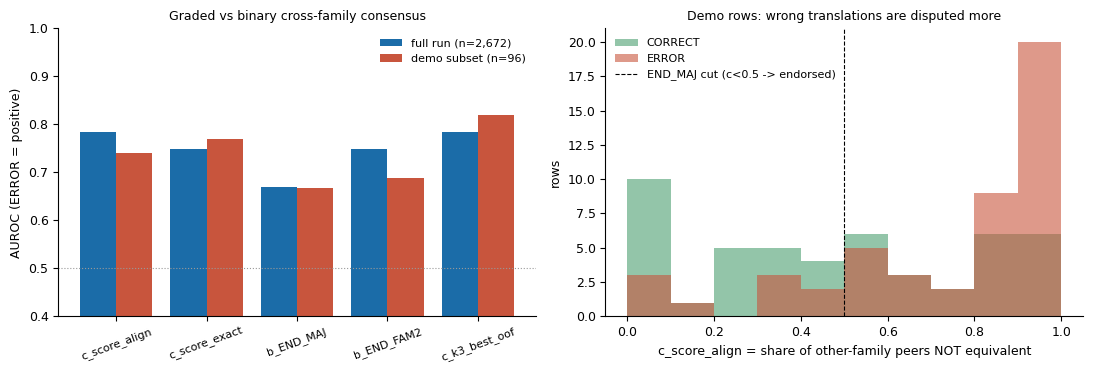

In [13]:
ma = out["metrics_agg"]
head = [("AUROC c_score_align (graded, frozen)", "auroc_c_score_align"), ("AUROC c_score_exact (aligner-free)", "auroc_c_score_exact"),
        ("AUROC END_MAJ (binary majority)", "auroc_b_END_MAJ"), ("delta graded - binary", "delta_graded_minus_binary"),
        ("END_MAJ e = P(endorsed | ERROR)", "e_maj_R_AB"), ("END_MAJ d = P(not endorsed | CORRECT)", "d_maj_R_AB"),
        ("NET Delta(e+d) words T3-T1", "net_delta_words"), ("SI_err (errors equivalent)", "si_err_mean"), ("SI_cor (corrects equivalent)", "si_cor_mean"),
        ("k95 (peers for 95% of max AUROC)", "k95"), ("k=3 cross-fitted best pool OOF AUROC", "m4_k3_crossfit_oof_auroc"),
        ("LOFO min delta", "lofo_min_delta"), ("eqmv non-transitivity rate", "nontransitivity_rate")]
print("(a) FULL RUN (R_AB, 2,672 scorable rows)")
print(pd.DataFrame([(n, ma.get(k)) for n, k in head], columns=["metric", "value"]).to_string(index=False, float_format=lambda v: f"{v:.3f}"))

ex = [e for e in out["datasets"][0]["examples"] if e["metadata_consensus_scorable"]]
y = np.array([e["output"] == "ERROR" for e in ex], int)
cols = {"c_score_align": "predict_c_score_align", "c_score_exact": "predict_c_score_exact", "b_END_MAJ": "predict_b_endmaj",
        "b_END_FAM2": "predict_b_endfam2", "c_k3_best_oof": "predict_c_k3_best_oof"}
demo = {}
if 0 < y.sum() < len(y):
    for nm, k in cols.items():
        s = np.array([float(e[k]) if e[k] != "NA" else np.nan for e in ex]); ok = ~np.isnan(s)
        demo[nm] = roc_auc_score(y[ok], s[ok])
    endorsed = np.array([e["eval_endorsed_maj"] for e in ex])
    e_rate, d_rate = endorsed[y == 1].mean(), 1 - endorsed[y == 0].mean()
    print(f"\n(b) DEMO SUBSET ({len(ex)} scorable rows: {y.sum()} ERROR / {len(y) - y.sum()} CORRECT)")
    print(pd.DataFrame(demo.items(), columns=["score", "AUROC"]).to_string(index=False, float_format=lambda v: f"{v:.3f}"))
    print(f"END_MAJ on demo rows: e={e_rate:.3f}  d={d_rate:.3f}  -> 1-(e+d)/2 = {1 - (e_rate + d_rate) / 2:.3f} (= AUROC b_END_MAJ, bookkeeping identity)")

print("\n(c) VERDICTS")
for k, v in out["metadata"]["verdicts"].items():
    print(f"  {k:9s} {v.get('verdict', v) if isinstance(v, dict) else v}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
full = {"c_score_align": ma["auroc_c_score_align"], "c_score_exact": ma["auroc_c_score_exact"], "b_END_MAJ": ma["auroc_b_END_MAJ"],
        "b_END_FAM2": ma.get("auroc_b_fam2_R_AB", np.nan), "c_k3_best_oof": ma["m4_k3_crossfit_oof_auroc"]}
x = np.arange(len(full))
ax[0].bar(x - 0.2, list(full.values()), 0.4, label="full run (n=2,672)", color="#1b6ca8")
ax[0].bar(x + 0.2, [demo.get(k, np.nan) for k in full], 0.4, label=f"demo subset (n={len(ex)})", color="#c8553d")
ax[0].axhline(0.5, color="#999999", ls=":", lw=0.8)
ax[0].set_xticks(x, list(full), rotation=20, fontsize=8); ax[0].set_ylim(0.4, 1); ax[0].set_ylabel("AUROC (ERROR = positive)")
ax[0].legend(fontsize=8, frameon=False); ax[0].set_title("Graded vs binary cross-family consensus", fontsize=9)
for lab, col in (("CORRECT", "#4c9f70"), ("ERROR", "#c8553d")):
    s = [float(e["predict_c_score_align"]) for e in ex if e["output"] == lab and e["predict_c_score_align"] != "NA"]
    ax[1].hist(s, bins=np.linspace(0, 1, 11), alpha=0.6, color=col, label=lab)
ax[1].axvline(0.5, color="k", ls="--", lw=0.8, label="END_MAJ cut (c<0.5 -> endorsed)")
ax[1].set_xlabel("c_score_align = share of other-family peers NOT equivalent"); ax[1].set_ylabel("rows")
ax[1].legend(fontsize=8, frameon=False); ax[1].set_title("Demo rows: wrong translations are disputed more", fontsize=9)
plt.tight_layout(); plt.show()